# Scaling plots for `g40` for NCMAS2026
Re-plotting data from https://github.com/ACCESS-NRI/access-models-scaling

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from io import StringIO

## ACCESS-OM3-25km global model

`data_str` and `total_str` data copied from 
https://github.com/ACCESS-NRI/access-models-scaling/blob/a1235d44165a4bc33d60449ec7f8fdaf4b695bdd/accessom3_global_25km.ipynb

In [2]:
data_str = """
	[MED] RunPhase1	[ICE] RunPhase1	[data component (ATM+ROF)] RunPhase1	[ICE+ATM+ROF] RunPhase1	[OCN] RunPhase1
__output_name	combine	combine	combine	combine	combine
cores					
13	0.770134	2.476387	0.048572	2.524960	NaN
39	0.194218	0.923992	0.015459	0.939451	NaN
52	NaN	NaN	NaN	NaN	11.415916
65	0.114097	0.556116	0.010202	0.566317	NaN
104	0.063127	0.325838	0.007056	0.332894	NaN
130	0.056014	0.334770	0.006104	0.340874	NaN
156	0.049846	0.287031	0.005707	0.292738	NaN
195	0.039801	0.240805	0.005194	0.246000	NaN
221	0.041471	0.210484	0.004989	0.215474	NaN
260	0.035388	0.182464	0.004712	0.187176	NaN
299	0.032911	0.159636	0.004412	0.164049	NaN
390	0.034113	0.143718	0.004433	0.148151	NaN
416	0.029475	0.169685	0.004404	0.174089	1.229848
442	0.028836	0.133795	0.004350	0.138145	NaN
468	0.026352	0.131689	0.004364	0.136054	NaN
494	0.025930	0.126408	0.004458	0.130867	NaN
624	NaN	NaN	NaN	NaN	0.867093
832	NaN	NaN	NaN	NaN	0.716020
884	NaN	NaN	NaN	NaN	0.607979
1040	NaN	NaN	NaN	NaN	0.516780
1248	NaN	NaN	NaN	NaN	0.448486
1456	NaN	NaN	NaN	NaN	0.393636
1664	NaN	NaN	NaN	NaN	0.346256
1872	NaN	NaN	NaN	NaN	0.318095
2080	NaN	NaN	NaN	NaN	0.306458
2288	NaN	NaN	NaN	NaN	0.278128
2392	NaN	NaN	NaN	NaN	0.268670
2496	NaN	NaN	NaN	NaN	0.264262
2600	NaN	NaN	NaN	NaN	0.268796
"""

In [3]:
names=['Cores', 'Coupler', 'CICE6', 'Forcing', 'Coupler+CICE6+ATM+ROF', 'MOM6']

data = pd.read_csv(StringIO(data_str),
            sep='\t',
            skiprows=[0, 1, 2, 3],
            names=names)

data

,Cores,Coupler,CICE6,Forcing,Coupler+CICE6+ATM+ROF,MOM6
0,13,0.770134,2.476387,0.048572,2.524960,NaN
1,39,0.194218,0.923992,0.015459,0.939451,NaN
2,52,NaN,NaN,NaN,NaN,11.415916
3,65,0.114097,0.556116,0.010202,0.566317,NaN
4,104,0.063127,0.325838,0.007056,0.332894,NaN
5,130,0.056014,0.334770,0.006104,0.340874,NaN
6,156,0.049846,0.287031,0.005707,0.292738,NaN
7,195,0.039801,0.240805,0.005194,0.246000,NaN
8,221,0.041471,0.210484,0.004989,0.215474,NaN
9,260,0.035388,0.182464,0.004712,0.187176,NaN


In [4]:
total_str = """
	[total] RunPhase1
__output_name	combine
cores	
65	11.645170
455	1.419045
689	0.918537
936	0.752245
1014	0.638229
1196	0.543861
1443	0.470674
1677	0.416001
1924	0.367715
2171	0.337132
2470	0.324364
2704	0.297940
2834	0.289011
2964	0.281374
3094	0.284576
"""

In [5]:
total = pd.read_csv(StringIO(total_str),
            sep='\t',
            skiprows=[0, 1, 2, 3],
            names=['Cores', 'Total'])
total

,Cores,Total
0,65,11.645170
1,455,1.419045
2,689,0.918537
3,936,0.752245
4,1014,0.638229
5,1196,0.543861
6,1443,0.470674
7,1677,0.416001
8,1924,0.367715
9,2171,0.337132


<Figure size 640x480 with 0 Axes>

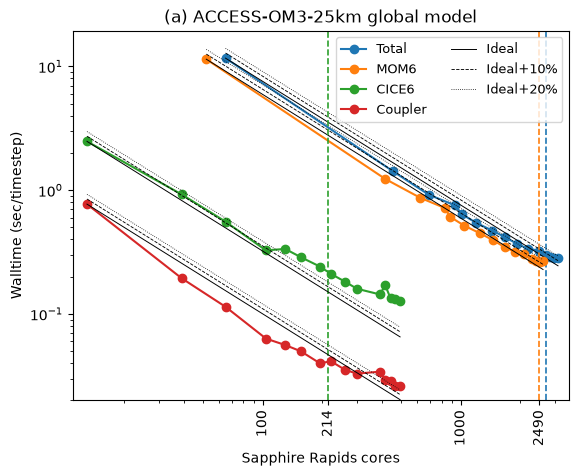

In [6]:
plt.figure()
fig, ax = plt.subplots()

d = total.dropna()
p = plt.loglog(d.set_index('Cores'),
         marker='o', label='Total')
extraticks = list()
extraticks.append(2704)
plt.axvline(extraticks[-1], color=p[-1].get_color(),
           linestyle='--', linewidth=1.2)        
for i, linestyle in enumerate(['-', '--', ':']):
    s = 1+i/10
    plt.loglog([d.iloc[0,0], d.iloc[-1,0]],
               [s*d.iloc[0,1], s*d.iloc[0,1]*d.iloc[0,0]/d.iloc[-1,0]],
               color='k',#p[-1].get_color(),
               linestyle=linestyle, linewidth=0.7/s,
              )

cols = {'MOM6': 2490, 'CICE6': 214, 'Coupler': 214}
for n, v in cols.items():
    d = data.loc[:, ['Cores', n]].dropna()
    p = plt.loglog(d.set_index(names[0]),
             marker='o', label=n)
    if n in ['MOM6', 'CICE6']:
        plt.axvline(v, color=p[-1].get_color(),
                   linestyle='--', linewidth=1.2)
        extraticks.append(v)
    for i, linestyle in enumerate(['-', '--', ':']):
        s = 1+i/10
        plt.loglog([d.iloc[0,0], d.iloc[-1,0]],
                   [s*d.iloc[0,1], s*d.iloc[0,1]*d.iloc[0,0]/d.iloc[-1,0]],
                   color='k',#p[-1].get_color(),
                   linestyle=linestyle, linewidth=0.7/s,
                   label=None if n != 'Coupler' else 'Ideal' if s == 1 else f'Ideal+{i*10}%'
                  )
plt.legend(ncol=2, fontsize=9)
plt.xticks(list(plt.xticks()[0]) + extraticks[1:], rotation=90)
plt.xlim([11, 3500])
plt.ylim([0.02, None])
ax.set_xticklabels([repr(int(x)) for x in ax.get_xticks()])
plt.xlabel('Sapphire Rapids cores')
plt.ylabel('Walltime (sec/timestep)')
plt.title('(a) ACCESS-OM3-25km global model')
plt.savefig('scaling_ACCESS-OM3-25km.png', dpi=200, bbox_inches='tight')

## ACCESS-rOM3-panant-4km regional model

`pa_data_str` and `pa_total_str` data copied from 
https://github.com/ACCESS-NRI/access-models-scaling/blob/0f764f31f318378a4fca3d98b7bc1745d7c2c3db/accessom3_panan_4km.ipynb

In [7]:
pa_data_str = """
	[MED] RunPhase1	[ICE] RunPhase1	[data component (ATM+ROF)] RunPhase1	[ICE+ATM+ROF] RunPhase1	[OCN] RunPhase1
__output_name	combine	combine	combine	combine	combine
cores					
52	0.893847	5.942429	0.043715	5.986144	NaN
104	NaN	NaN	NaN	NaN	18.017289
156	0.204481	2.500123	0.014002	2.514125	NaN
260	0.134125	1.519018	0.009012	1.528029	NaN
364	0.111363	1.084217	0.008284	1.092501	NaN
468	0.096087	0.931354	0.006290	0.937644	NaN
520	NaN	NaN	NaN	NaN	3.240968
676	0.095057	0.624489	0.005811	0.630300	NaN
780	0.087625	0.551636	0.007167	0.558802	NaN
884	0.075792	0.536127	0.005243	0.541370	NaN
936	NaN	NaN	NaN	NaN	1.874886
988	0.067301	0.466946	0.005197	0.472143	NaN
1092	0.065974	0.498553	0.005362	0.503915	NaN
1352	NaN	NaN	NaN	NaN	1.373672
1768	NaN	NaN	NaN	NaN	1.101215
2600	NaN	NaN	NaN	NaN	0.807172
3016	NaN	NaN	NaN	NaN	0.713162
3432	NaN	NaN	NaN	NaN	0.671969
3848	NaN	NaN	NaN	NaN	0.637259
4264	NaN	NaN	NaN	NaN	0.592749
"""

In [8]:
pa_names=['Cores', 'Coupler', 'CICE6', 'Forcing', 'Coupler+CICE6+ATM+ROF', 'MOM6']

pa_data = pd.read_csv(StringIO(pa_data_str),
            sep='\t',
            skiprows=[0, 1, 2, 3],
            names=pa_names)

pa_data

,Cores,Coupler,CICE6,Forcing,Coupler+CICE6+ATM+ROF,MOM6
0,52,0.893847,5.942429,0.043715,5.986144,NaN
1,104,NaN,NaN,NaN,NaN,18.017289
2,156,0.204481,2.500123,0.014002,2.514125,NaN
3,260,0.134125,1.519018,0.009012,1.528029,NaN
4,364,0.111363,1.084217,0.008284,1.092501,NaN
5,468,0.096087,0.931354,0.006290,0.937644,NaN
6,520,NaN,NaN,NaN,NaN,3.240968
7,676,0.095057,0.624489,0.005811,0.630300,NaN
8,780,0.087625,0.551636,0.007167,0.558802,NaN
9,884,0.075792,0.536127,0.005243,0.541370,NaN


In [9]:
pa_total_str = """
	[total] RunPhase1
__output_name	combine
cores	
156	18.258638
676	3.559722
1196	2.087915
1716	1.526584
2236	1.244262
3276	0.895691
3796	0.798068
4316	0.749914
4836	0.695364
5356	0.668723
"""

In [10]:
pa_total = pd.read_csv(StringIO(pa_total_str),
            sep='\t',
            skiprows=[0, 1, 2, 3],
            names=['Cores', 'Total'])
pa_total

,Cores,Total
0,156,18.258638
1,676,3.559722
2,1196,2.087915
3,1716,1.526584
4,2236,1.244262
5,3276,0.895691
6,3796,0.798068
7,4316,0.749914
8,4836,0.695364
9,5356,0.668723


<Figure size 640x480 with 0 Axes>

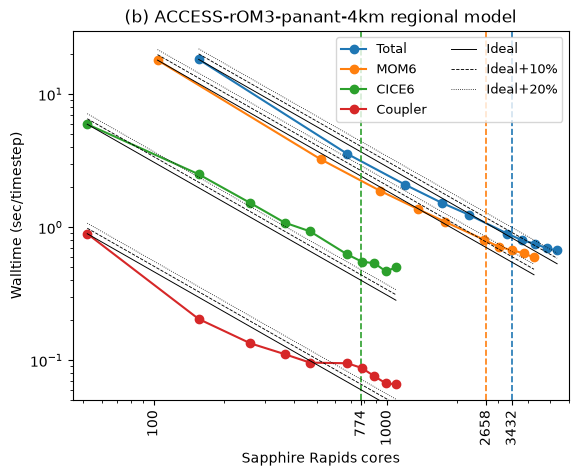

In [11]:
plt.figure()
fig, ax = plt.subplots()

d = pa_total.dropna()
p = plt.loglog(d.set_index('Cores'),
         marker='o', label='Total')
extraticks = list()
extraticks.append(3432)
plt.axvline(extraticks[-1], color=p[-1].get_color(),
           linestyle='--', linewidth=1.2)        
for i, linestyle in enumerate(['-', '--', ':']):
    s = 1+i/10
    plt.loglog([d.iloc[0,0], d.iloc[-1,0]],
               [s*d.iloc[0,1], s*d.iloc[0,1]*d.iloc[0,0]/d.iloc[-1,0]],
               color='k',#p[-1].get_color(),
               linestyle=linestyle, linewidth=0.7/s,
              )

cols = {'MOM6': 2658, 'CICE6': 774, 'Coupler': 774}
for n, v in cols.items():
    d = pa_data.loc[:, ['Cores', n]].dropna()
    p = plt.loglog(d.set_index(names[0]),
             marker='o', label=n)
    if n in ['MOM6', 'CICE6']:
        plt.axvline(v, color=p[-1].get_color(),
                   linestyle='--', linewidth=1.2)
        extraticks.append(v)
    for i, linestyle in enumerate(['-', '--', ':']):
        s = 1+i/10
        plt.loglog([d.iloc[0,0], d.iloc[-1,0]],
                   [s*d.iloc[0,1], s*d.iloc[0,1]*d.iloc[0,0]/d.iloc[-1,0]],
                   color='k',#p[-1].get_color(),
                   linestyle=linestyle, linewidth=0.7/s,
                   label=None if n != 'Coupler' else 'Ideal' if s == 1 else f'Ideal+{i*10}%'
                  )

plt.legend(ncol=2, fontsize=9)
plt.xticks(list(plt.xticks()[0]) + extraticks, rotation=90)
plt.xlim([45, 6000])
plt.ylim([0.05, None])
ax.set_xticklabels([repr(int(x)) for x in ax.get_xticks()])
plt.xlabel('Sapphire Rapids cores')
plt.ylabel('Walltime (sec/timestep)')
plt.title('(b) ACCESS-rOM3-panant-4km regional model')
plt.savefig('scaling_ACCESS-rOM3-panant-4km.png', dpi=200, bbox_inches='tight')